<a href="https://colab.research.google.com/github/deltorobarba/astrophysics/blob/main/flrw_metric.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **FLRW metric (Robertson-Walker-Metric)**

The Friedmann-Lemaître-Robertson-Walker (FLRW) metric describes a homogeneous, isotropic expanding universe. It's widely used in cosmology to describe the large-scale structure of spacetime. The FLRW metric is given by:

$
ds^2 = -c^2 dt^2 + a(t)^2 \left[ \frac{dr^2}{1 - k r^2} + r^2 (d\theta^2 + \sin^2\theta \, d\phi^2) \right]
$

Where:
- \( ds^2 \): Spacetime interval (line element).
- \( c \): Speed of light.
- \( t \): Cosmic time.
- \( a(t) \): Scale factor of the universe.
- \( r, \theta, \phi \): Spherical coordinates.
- \( k \): Curvature constant (\( k = 1 \) for closed, \( k = 0 \) for flat, and \( k = -1 \) for open universes).

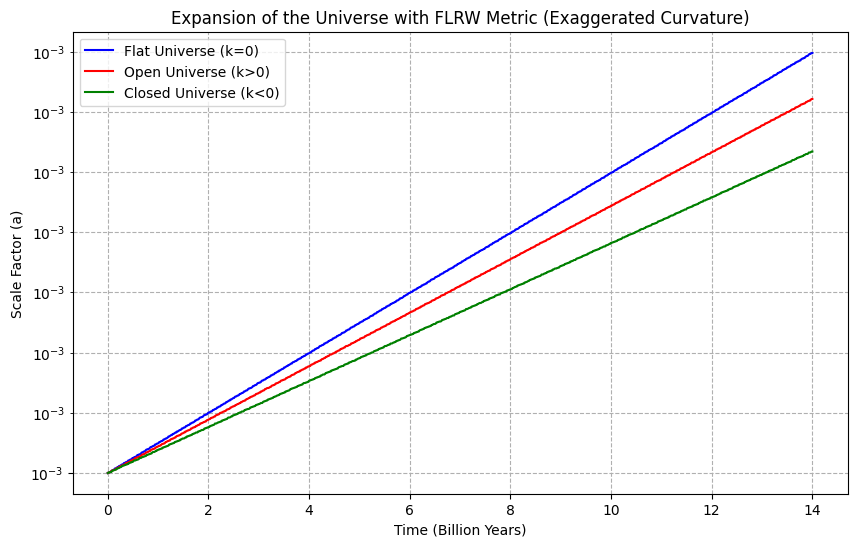

In [11]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.integrate import solve_ivp

# Cosmological constants
H0 = 70  # Hubble constant today in km/s/Mpc
Omega_m = 0.3  # Matter density parameter
Omega_r = 8.24e-5  # Radiation density parameter
Omega_Lambda = 0.7  # Dark energy density parameter
c = 3e5  # Speed of light in km/s

# Exaggerated Curvature parameters
Omega_k_flat = 100  # Flat universe
Omega_k_open = 0  # Larger positive value for open universe
Omega_k_closed = -100  # Larger negative value for closed universe

# Convert H0 from km/s/Mpc to s^-1
H0_s = H0 / (3.086e19)

# Generalized Friedmann equation including radiation, matter, curvature, and dark energy
def friedmann_eq_FLRW(t, a, Omega_k):
    # da/dt = H(a) * a, based on the FLRW metric
    return H0_s * np.sqrt(Omega_m / a**3 + Omega_r / a**4 + Omega_k / a**2 + Omega_Lambda) * a

# Time range in billions of years
time = np.linspace(0, 14, 1000)  # From 0 to 14 billion years

# Initial scale factor (early universe) adjusted
a0 = 0.001  # Start with a slightly larger scale factor for early universe

# Solve for a flat universe
sol_flat = solve_ivp(friedmann_eq_FLRW, [0, 14], [a0], t_eval=time, args=(Omega_k_flat,))

# Solve for an open universe
sol_open = solve_ivp(friedmann_eq_FLRW, [0, 14], [a0], t_eval=time, args=(Omega_k_open,))

# Solve for a closed universe
sol_closed = solve_ivp(friedmann_eq_FLRW, [0, 14], [a0], t_eval=time, args=(Omega_k_closed,))

# Plot the results with more exaggerated differences
plt.figure(figsize=(10, 6))
plt.plot(time, sol_flat.y[0], label='Flat Universe (k=0)', color='b')
plt.plot(time, sol_open.y[0], label='Open Universe (k>0)', color='r')
plt.plot(time, sol_closed.y[0], label='Closed Universe (k<0)', color='g')
plt.yscale('log')  # Logarithmic scale to emphasize differences
plt.title('Expansion of the Universe with FLRW Metric (Exaggerated Curvature)')
plt.xlabel('Time (Billion Years)')
plt.ylabel('Scale Factor (a)')
plt.grid(True, which="both", ls="--")
plt.legend()
plt.show()
